Supervised Learning on Census Income - 5/31/26 - halarc1407

In [2]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, roc_auc_score)
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "halarc1407"
# Load the Census Income dataset
data = pd.read_csv('census_income_dataset.csv')
display(Markdown("### Step 1.2: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(data.head())

### Step 1.2: Load the Dataset

Date: 2026-05-31

Student ID: halarc1407

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
display(Markdown("### Step 1.3: Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Concise summary
print(data.info())
# Descriptive statistics
display(data.describe())

### Step 1.3: Initial Exploration of the Dataset

Date: 2026-05-31

Student ID: halarc1407

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB
None


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [4]:
display(Markdown("### Step 1.4: Preprocess the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Check missing values
print(f"Missing values before:\n{data.isnull().sum()}")
# Fill missing categorical values with the mode
for column in data.select_dtypes(include=['object']).columns:
    data[column] = data[column].fillna(data[column].mode()[0])
# Fill numerical missing values with the median
for column in data.select_dtypes(include=[np.number]).columns:
    data[column] = data[column].fillna(data[column].median())
print(f"\nMissing values after: {data.isnull().sum().sum()}")

# Remove duplicates
print(f"\nDuplicate rows before: {data.duplicated().sum()}")
data = data.drop_duplicates()
print(f"Duplicate rows after: {data.duplicated().sum()}")

# Convert target to binary
data['income'] = data['income'].apply(lambda x: 1 if x == '>50K' else 0)

# One-hot encode categorical features
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)
print(f"\nFinal shape after encoding: {data.shape}")

# Split features and target
X = data.drop('income', axis=1)
y = data['income']

# Scale features (important for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

### Step 1.4: Preprocess the Data

Date: 2026-05-31

Student ID: halarc1407

Missing values before:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Missing values after: 0

Duplicate rows before: 29
Duplicate rows after: 0

Final shape after encoding: (48813, 101)

Training set size: (34169, 100)
Testing set size: (14644, 100)


In [5]:
display(Markdown("### Step 2.1: Implement K-Nearest Neighbors"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Fit the KNN model
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
# Predict on test data
y_pred = knn.predict(X_test)
print("KNN model trained and predictions made.")
print(f"First 20 predictions: {y_pred[:20]}")

### Step 2.1: Implement K-Nearest Neighbors

Date: 2026-05-31

Student ID: halarc1407

KNN model trained and predictions made.
First 20 predictions: [1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [6]:
display(Markdown("### Step 2.2: Evaluate the Baseline KNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Performance metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

### Step 2.2: Evaluate the Baseline KNN Model

Date: 2026-05-31

Student ID: halarc1407

Accuracy Score: 0.8341
Precision: 0.4748
Recall: 0.3082
F1 Score: 0.3738

Confusion Matrix:
[[11490   802]
 [ 1627   725]]


In [7]:
display(Markdown("### Step 3.1: GridSearchCV for Hyperparameter Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Define the parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
# Run GridSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

### Step 3.1: GridSearchCV for Hyperparameter Tuning

Date: 2026-05-31

Student ID: halarc1407

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Best Cross-Validation Score: 0.8401


In [8]:
display(Markdown("### Step 3.2: Evaluate the Tuned KNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Use best estimator
best_knn = grid_search.best_estimator_
y_pred_tuned = best_knn.predict(X_test)
# Performance metrics
print(f"Tuned Accuracy Score: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned F1 Score: {f1_score(y_test, y_pred_tuned):.4f}")
print("\nTuned Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

### Step 3.2: Evaluate the Tuned KNN Model

Date: 2026-05-31

Student ID: halarc1407

Tuned Accuracy Score: 0.8405
Tuned Precision: 0.5064
Tuned Recall: 0.2866
Tuned F1 Score: 0.3660

Tuned Confusion Matrix:
[[11635   657]
 [ 1678   674]]


### Step 4: Visualizations - Confusion Matrix Heatmap and ROC Curve

Date: 2026-05-31

Student ID: halarc1407

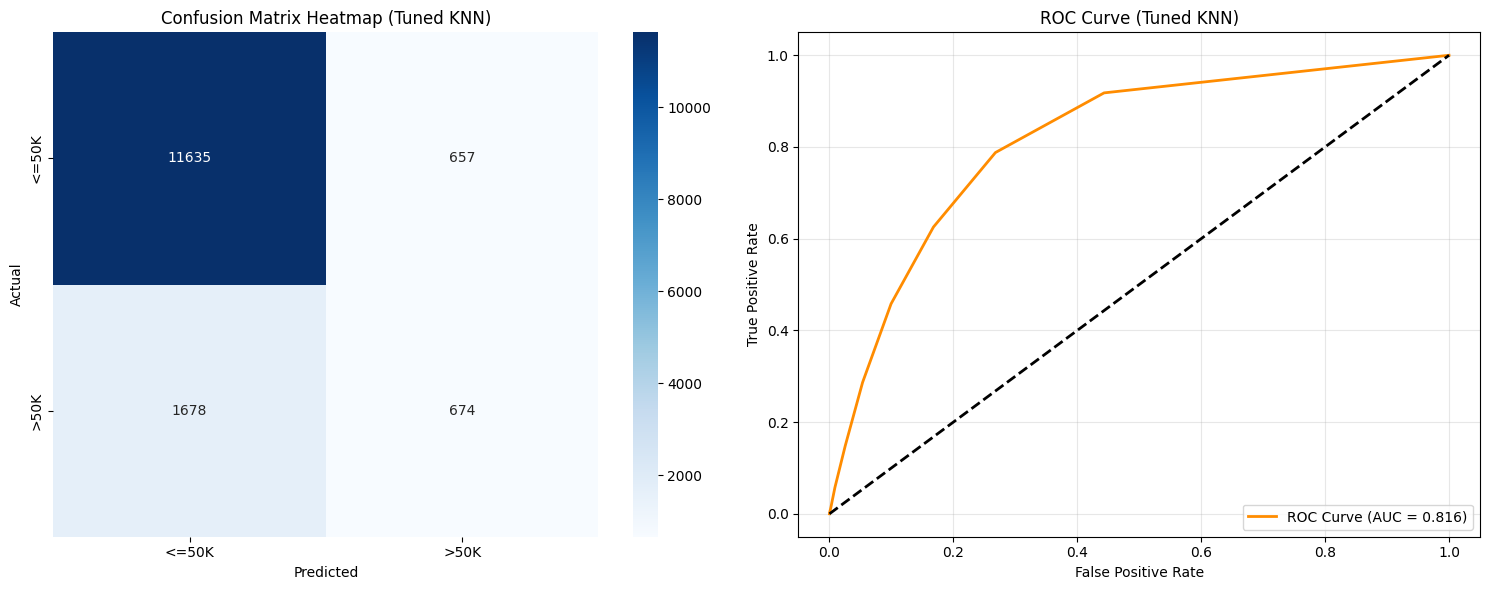

In [9]:
display(Markdown("### Step 4: Visualizations - Confusion Matrix Heatmap and ROC Curve"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_tuned)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[0].set_title('Confusion Matrix Heatmap (Tuned KNN)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve and AUC
y_pred_proba = best_knn.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})', color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Tuned KNN)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()